In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
df = pd.read_csv(
    'barbasi_albert/size_200/kempe_welfare_barbasi_albert_200_8_results.csv',
    converters={
        'kempe_influence_by_community': eval,
        'welfare_influence_by_community': eval,
    },
)

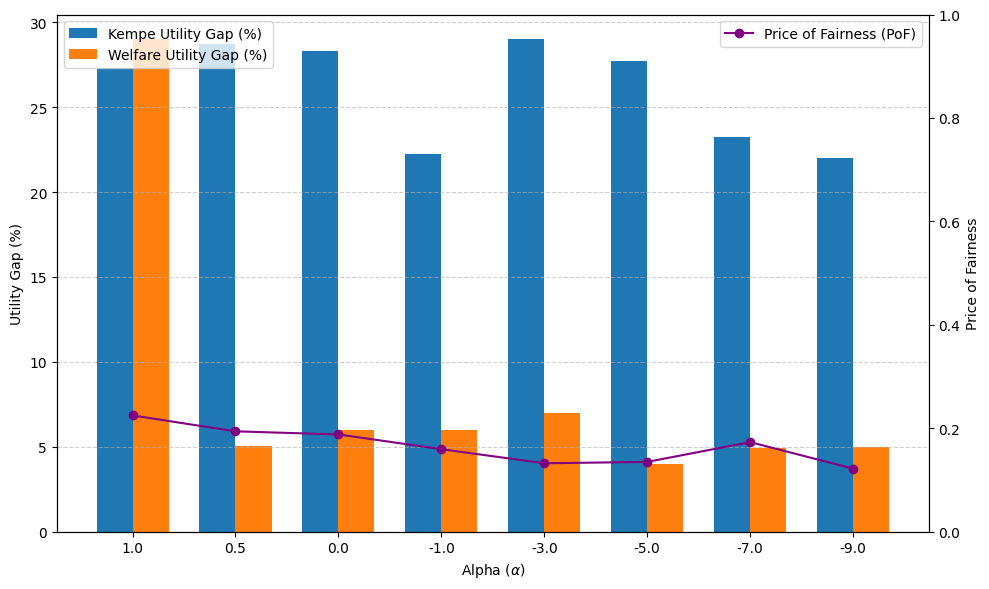

In [98]:
for method in ['kempe', 'welfare']:
    df[f'{method}_gap'] = df[f'{method}_influence_by_community'].apply(
        lambda d: (max(d.values()) - min(d.values())) / sum(d.values()) * 100
    )

df['PoF'] = 1 - (df['fair_total_influence'] / df['org_total_influence'])

x = np.arange(len(df))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(x - bar_width / 2, df['kempe_gap'], width=bar_width, label='Kempe Utility Gap (%)')
ax1.bar(x + bar_width / 2, df['welfare_gap'], width=bar_width, label='Welfare Utility Gap (%)')
ax1.set_xlabel(r'Alpha ($\alpha$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(df['alpha'])
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(x, df['PoF'], color='purple', marker='o', label='Price of Fairness (PoF)')
ax2.set_ylabel('Price of Fairness')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
seed_sizes = [1, 3, 5, 7, 9]
all_results = []

for k in seed_sizes:
    df = pd.read_csv(f'barbasi_albert/size_200/kempe_welfare_barbasi_albert_200_{k}_results.csv')

    for method in ['kempe', 'welfare']:
        df[f'{method}_gap'] = df[f'{method}_influence_by_community'].apply(
            lambda d: (max(eval(d).values()) - min(eval(d).values())) / sum(eval(d).values()) * 100
        )

    df['PoF'] = 1 - (df['fair_total_influence'] / df['org_total_influence'])

    df['seed_size'] = k

    all_results.append(df)

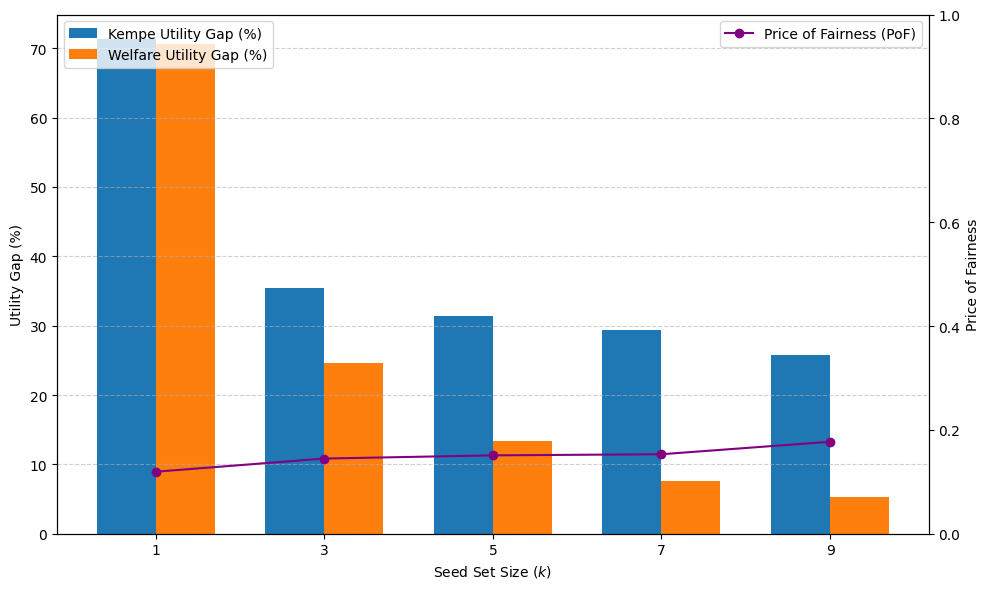

In [99]:
combined_df = pd.concat(all_results, ignore_index=True)

agg = combined_df.groupby('seed_size').agg(
    {
        'kempe_gap': 'mean',
        'welfare_gap': 'mean',
        'PoF': 'mean',
    }
).reset_index()

x = np.arange(len(seed_sizes))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(x - bar_width / 2, agg['kempe_gap'], width=bar_width, label='Kempe Utility Gap (%)')
ax1.bar(x + bar_width / 2, agg['welfare_gap'], width=bar_width, label='Welfare Utility Gap (%)')

ax1.set_xlabel('Seed Set Size ($k$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(agg['seed_size'])
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(x, agg['PoF'], color='purple', marker='o', label='Price of Fairness (PoF)')
ax2.set_ylabel('Price of Fairness')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')


plt.tight_layout()
plt.show()